In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import lightkurve as lk
import astropy.units as u
from lightkurve import LightCurve

from fgivenx import plot_contours, plot_lines, plot_dkl
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from nestar.ARIMA import ARIMA_fast, ARIMA_forecast
from nestar.ARIMA_ns import ARIMA_Nested_Sampler
from nestar.priors import normal_prior
from nestar.model_comparison_utils import ARIMA_model_comparison
from nestar import arima_results as ar

/Users/ajinkya/myenv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


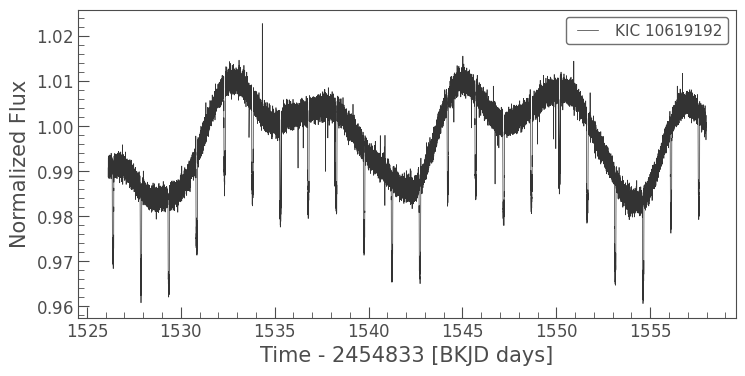

In [4]:
all_lcs = lk.search_lightcurve('Kepler 17',mission='Kepler')
lcf = all_lcs[40].download()
original_lc = lcf.remove_outliers(sigma=5).normalize().remove_nans()
original_lc.plot()
plt.show()

In [5]:
time = np.array(original_lc['time'].value)
flux = np.array(original_lc['flux'].value)

0.02111501723265974


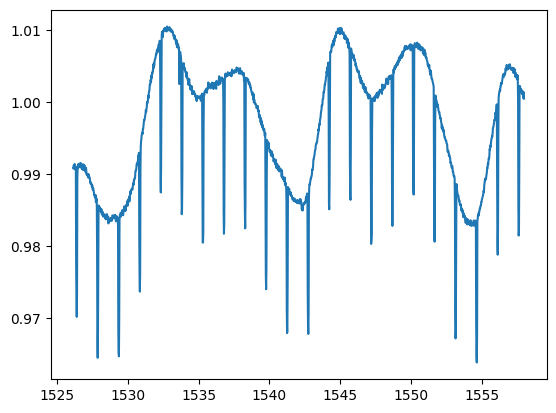

In [6]:
print(max(np.diff(time))) #use this for binning the data
lc = lcf.remove_outliers(sigma=5).normalize().remove_nans().bin(time_bin_size=0.02111501723265974)
flux = np.array(lc['flux'].value)
flux_err = np.array(lc['flux_err'].value)
time = np.sort(np.array(lc['time'].value))
plt.plot(time,flux)
plt.show()

In [7]:
from model_comparison_utils import stationarity_test

stationarity_test(flux)

Results of Dickey-Fuller Test:
Test Statistic                   -2.438782
p-value                           0.131088
#Lags Used                       14.000000
Number of Observations Used    1493.000000
Critical Value (1%)              -3.434738
Critical Value (5%)              -2.863478
Critical Value (10%)             -2.567802
dtype: float64
Non stationarity acc to ADF test
Results of KPSS Test:
Test Statistic            0.431541
p-value                   0.063560
Lags Used                24.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Series stationarity acc to KPSS test


/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/model_comparison_utils.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if kpss_output[1] < 0.05:


(None, None)

In [9]:
logP_d1 = ARIMA_model_comparison(data=flux,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=33,file_name='Heatmap Data/kepler17_d1.txt')
logP_d1.run()

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_13597/454804833.py:1: UserWarning: 'Heatmap Data/kepler17_d1.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  logP_d1 = ARIMA_model_comparison(data=flux,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=33,file_name='Heatmap Data/kepler17_d1.txt')
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_13597/454804833.py:2: UserWarning: 'Heatmap Data/kepler17_d1.txt' already exists and will be overwritten by this run. 
  logP_d1.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 7100 dead points [00:17, 399.30 dead points/s]


Finished Nested Sampling with a total runtime of : 18.40 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 5779.072548388321 ; Error : 0.4383904556390698
V : 0.68247 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.382
Highest Evidence so far : 5779.072548388321 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 7400 dead points [00:28, 263.98 dead points/s]


...

Finished Nested Sampling with a total runtime of : 1275.70 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 5) : 7087.285438200059 ; Error : 0.7993975805913105
V : 0.000145 ; D0 Occam : -24.893 ; Net prior-volume effect : -16.054
Highest Evidence so far : 7194.660121453294 for order : (1, 1, 5)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 6) model...
Acceptance rate: 0.0001, Total drawn: 400000
Acceptance rate: 0.0001, Total drawn: 600000
Acceptance rate: 0.0001, Total drawn: 800000
Acceptance rate: 0.0001, Total drawn: 1000000
Acceptance rate: 0.0001, Total drawn: 1200000
Acceptance rate: 0.0001, Total drawn: 1400000
Acceptance rate: 0.0001, Total drawn: 1600000
Acceptance rate: 0.0001, Total drawn: 1800000
Acceptance rate: 0.0001, Total drawn: 2000000
Acceptance rate: 0.0001, Total drawn: 2200000
Acceptance rate: 0.0001, Total drawn: 2400000
Acceptance rate: 

Dead points: 25000 dead points [34:30, 12.07 dead points/s]


Finished Nested Sampling with a total runtime of : 2071.99 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 6) : 7103.118603567386 ; Error : 0.9845427527935304
V : 5.5e-05 ; D0 Occam : -23.924 ; Net prior-volume effect : -14.116
Highest Evidence so far : 7194.660121453294 for order : (1, 1, 5)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (7, 1, 7) model...
Acceptance rate: 0.0000, Total drawn: 400000
Acceptance rate: 0.0000, Total drawn: 600000
Acceptance rate: 0.0000, Total drawn: 800000
Acceptance rate: 0.0000, Total drawn: 1000000
Acceptance rate: 0.0000, Total drawn: 1200000
Acceptance rate: 0.0000, Total drawn: 1400000
Acceptance rate: 0.0000, Total drawn: 1600000
Acceptance rate: 0.0000, Total drawn: 1800000
Acceptance rate: 0.0000, Total drawn: 2000000
Acceptance rate: 0.0000, Total drawn: 2200000
Acceptance rate: 0.0000, Total drawn: 2400000
Acceptance rate: 0

Dead points: 24850 dead points [35:02, 11.82 dead points/s]


Finished Nested Sampling with a total runtime of : 2103.68 seconds
----------------------x-------------------x---------------------x------
Evidence for (7, 1, 7) : 7109.122895848238 ; Error : 0.8230136860373166
V : 1.9901960784313726e-05 ; D0 Occam : -21.171 ; Net prior-volume effect : -10.346
Highest Evidence so far : 7194.660121453294 for order : (1, 1, 5)
----------------------x-------------------x----------------------x-----


In [ ]:
logP_pacf = ARIMA_model_comparison(data=flux,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=30,file_name='Heatmap Data/kepler17_d1_pacf.txt',prior_type="pacf")
logP_pacf.run()
#PACF agree with normal prior

/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_13597/151911031.py:1: UserWarning: 'Heatmap Data/kepler17_d1_pacf.txt' already exists and will be overwritten by this run. If you meant to keep it, rename/move it (or change file_name) before calling .run().
  logP_pacf = ARIMA_model_comparison(data=flux,max_p=7,max_q=7,d=1,num_live=200,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=30,file_name='Heatmap Data/kepler17_d1_pacf.txt',prior_type="pacf")
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_13597/151911031.py:2: UserWarning: 'Heatmap Data/kepler17_d1_pacf.txt' already exists and will be overwritten by this run. 
  logP_pacf.run()


Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 6900 dead points [00:17, 393.67 dead points/s]


Finished Nested Sampling with a total runtime of : 17.91 seconds
----------------------x-------------------x---------------------x------
Evidence for (0, 1, 1) : 5780.333168457144 ; Error : 0.45792440967033066
V : 1.0 ; D0 Occam : 0.000 ; Net prior-volume effect : 0.000
Highest Evidence so far : 5780.333168457144 for order : (0, 1, 1)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (0, 1, 2) model...


Dead points: 7700 dead points [00:27, 280.66 dead points/s]


...

Finished Nested Sampling with a total runtime of : 6313.86 seconds
----------------------x-------------------x---------------------x------
Evidence for (3, 1, 7) : 7137.19816982427 ; Error : 0.6992269984708276
V : 1.0 ; D0 Occam : -12.544 ; Net prior-volume effect : -12.544
Highest Evidence so far : 7194.105097745164 for order : (1, 1, 5)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (4, 1, 0) model...


Dead points: 18850 dead points [03:49, 82.28 dead points/s]


Finished Nested Sampling with a total runtime of : 229.96 seconds
----------------------x-------------------x---------------------x------
Evidence for (4, 1, 0) : 6981.868326723457 ; Error : 0.6915715974947618
V : 1.0 ; D0 Occam : -23.461 ; Net prior-volume effect : -23.461
Highest Evidence so far : 7194.105097745164 for order : (1, 1, 5)
----------------------x-------------------x----------------------x-----
Running Nested Sampling for fitting ARIMA (4, 1, 1) model...


Dead points: 21250 dead points [06:04, 58.25 dead points/s]


KeyboardInterrupt: 

In [8]:
##Tau sensitivity checks around best-fit neighbour and extreme models:
orders = [(1,1,5),(1,1,6),(1,1,4),(0,1,5),(0,1,6),(0,1,4),(2,1,5),(2,1,6),(2,1,4),(7,1,7),(1,1,0),(0,1,1)]

tau_evidences = []
tau_err = []
for tau in [1.7,15]:
 neighbour_evidences = []
 neighbour_evidences_err = []
 for order in orders:
    test_model = ARIMA_ns.ARIMA_Nested_Sampler(data=flux,order=order,num_live=100,num_delete=50,mu_mean=0,mu_scale=tau,seed=30)
    evidence = test_model.log_evidence
    neighbour_evidences.append(evidence)
    neighbour_evidences_err.append(test_model.log_evidence_err)
 tau_evidences.append(neighbour_evidences)
 tau_err.append(neighbour_evidences_err)
 print(neighbour_evidences)
 print(neighbour_evidences_err)

Running Nested Sampling for fitting ARIMA (1, 1, 5) model...


Dead points: 5200 dead points [02:14, 38.62 dead points/s]


Finished Nested Sampling with a total runtime of : 136.20 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 6) model...


Dead points: 4950 dead points [02:10, 37.88 dead points/s]


Finished Nested Sampling with a total runtime of : 131.13 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 4) model...


...

Finished Nested Sampling with a total runtime of : 648.01 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 0) model...


/Users/ajinkya/myenv/lib/python3.13/site-packages/anesthetic/samples.py:1336: RuntimeWarning: 550 out of 4900 samples have logL <= logL_birth,
532 of which have logL == logL_birth.
This may just indicate numerical rounding errors at the peak of the likelihood, but further investigation of the chains files is recommended.
Dropping the invalid samples.
  warnings.warn(
Dead points: 3950 dead points [00:14, 270.01 dead points/s]


Finished Nested Sampling with a total runtime of : 15.01 seconds
Running Nested Sampling for fitting ARIMA (0, 1, 1) model...


Dead points: 3150 dead points [00:07, 409.61 dead points/s]


Finished Nested Sampling with a total runtime of : 7.94 seconds
[np.float64(7191.258441659118), np.float64(7186.446658551812), np.float64(7178.02516710167), np.float64(6942.301680959427), np.float64(6979.930430867379), np.float64(6882.3146982444505), np.float64(7119.054043276443), np.float64(7171.976413558095), np.float64(7166.287142506618), np.float64(6418.347948323418), np.float64(6812.182486479357), np.float64(5776.963539682539)]
[np.float64(0.9874473654128835), np.float64(0.9347987271228824), np.float64(1.0359174492725771), np.float64(0.9322199670663766), np.float64(0.7857503900375564), np.float64(0.8070361679054755), np.float64(1.4010386737523153), np.float64(1.027446744694338), np.float64(1.0226144507877326), np.float64(0.9795725207581704), np.float64(0.7660056070894823), np.float64(0.7092326539447077)]


In [9]:
print(tau_evidences[0])
print(tau_err[0])
print(tau_evidences[1])
print(tau_err[1])

[np.float64(7189.736923264888), np.float64(7193.699850553734), np.float64(7193.5378889550075), np.float64(6944.6895381855375), np.float64(6981.060362204435), np.float64(6884.9752317566135), np.float64(7191.440206534501), np.float64(7179.352242336632), np.float64(7177.339484859177), np.float64(7143.488706898701), np.float64(6819.703305830785), np.float64(5778.658150154577)]
[np.float64(0.9500047976378588), np.float64(0.9642121849478225), np.float64(0.699823191216154), np.float64(0.7617948283437983), np.float64(0.769174107940996), np.float64(0.7657472101070855), np.float64(0.9374443169152904), np.float64(1.0804045328051477), np.float64(0.909373191217825), np.float64(1.1063630734146823), np.float64(0.6589080172729165), np.float64(0.6633221915051922)]
[np.float64(7191.258441659118), np.float64(7186.446658551812), np.float64(7178.02516710167), np.float64(6942.301680959427), np.float64(6979.930430867379), np.float64(6882.3146982444505), np.float64(7119.054043276443), np.float64(7171.97641355

In [13]:
model_kepler_15 = ARIMA_ns.ARIMA_Nested_Sampler(data=flux,order=(1,1,5),num_live=1000,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=50)
model_kepler_16 = ARIMA_ns.ARIMA_Nested_Sampler(data=flux,order=(1,1,6),num_live=1000,num_delete=50,mu_mean=1,mu_scale=5,meas_sigma=None,seed=50)

Running Nested Sampling for fitting ARIMA (1, 1, 5) model...


Dead points: 64850 dead points [29:06, 37.14 dead points/s]


Finished Nested Sampling with a total runtime of : 1748.00 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 6) model...


Dead points: 67400 dead points [33:26, 33.60 dead points/s]


Finished Nested Sampling with a total runtime of : 2007.19 seconds


In [ ]:
model_kepler_15_tau= ARIMA_ns.ARIMA_Nested_Sampler(data=flux,order=(1,1,5),num_live=500,num_delete=50,mu_mean=1,mu_scale=5/3,meas_sigma=None,seed=50)
model_kepler_16_tau = ARIMA_ns.ARIMA_Nested_Sampler(data=flux,order=(1,1,6),num_live=500,num_delete=50,mu_mean=1,mu_scale=5/3,meas_sigma=None,seed=50) #tau/3 check

Running Nested Sampling for fitting ARIMA (1, 1, 5) model...


Dead points: 30250 dead points [12:07, 41.58 dead points/s]


Finished Nested Sampling with a total runtime of : 728.92 seconds
Running Nested Sampling for fitting ARIMA (1, 1, 6) model...


Dead points: 25900 dead points [12:58, 26.85 dead points/s]

In [14]:
model_kepler_15.summary()

||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 1748.00 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9977923964004571
Posterior mean for theta_1 : 0.3849398968443713
Posterior mean for theta_2 : 0.07927889654154774
Posterior mean for theta_3 : -0.2736726927782577
Posterior mean for theta_4 : -0.6556332264709909
Posterior mean for theta_5 : -0.09710541450638792
Posterior mean for sigma : 0.001972971846327027
Posterior mean for mu : 0.0001233830912492498
Posterior mean for init_y_1 : 2.4375576247539404e-05
---------------------------------------------------
Log Evidence: 7194.37 ± 0.23
-------x----------------x-------------x------------


In [16]:
model_kepler_16.summary()

||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 2007.19 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9963117886486461
Posterior mean for theta_1 : 0.3841304059667204
Posterior mean for theta_2 : 0.06920846995087994
Posterior mean for theta_3 : -0.27878981768802774
Posterior mean for theta_4 : -0.6531348129202095
Posterior mean for theta_5 : -0.08968966781213147
Posterior mean for theta_6 : 0.01715611817869334
Posterior mean for sigma : 0.001978227916231877
Posterior mean for mu : -2.282766308584684e-06
Posterior mean for init_y_1 : 2.850252490026689e-05
---------------------------------------------------
Log Evidence: 7191.82 ± 0.22
-------x----------------x-------------x------------


PosteriorResults: order=(1, 1, 5), prior_type='normal' (given)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1006: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


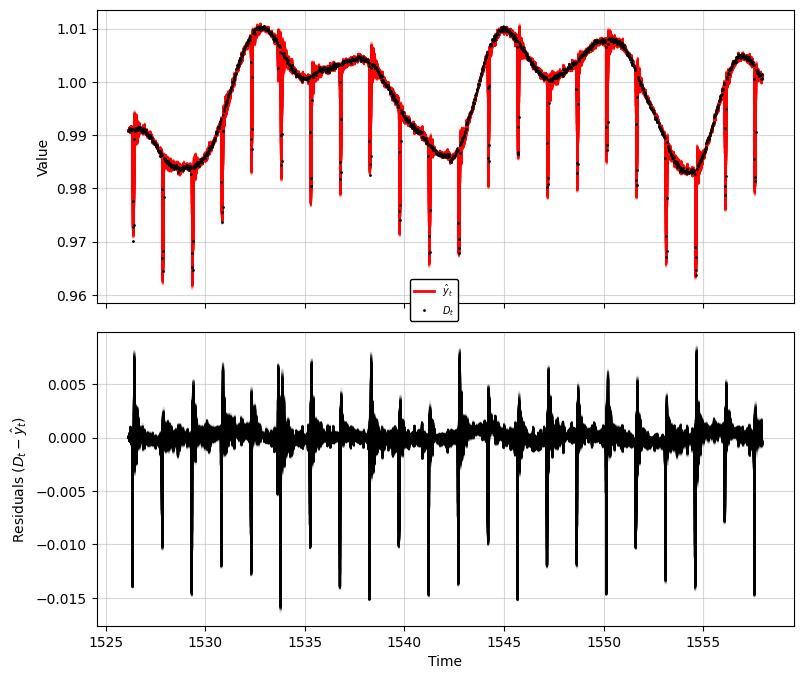

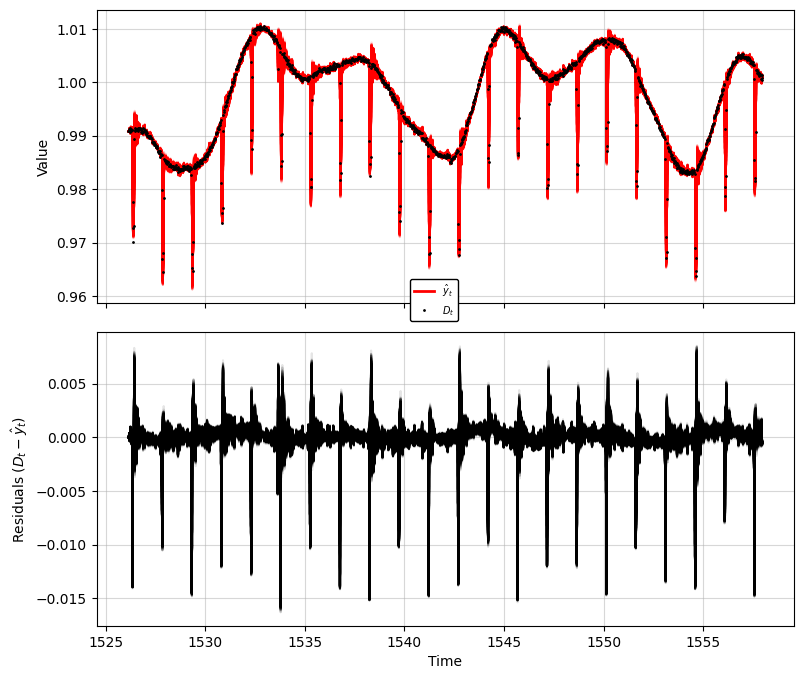

In [12]:
model_kepler.insample_forecast(time)
plt.show()

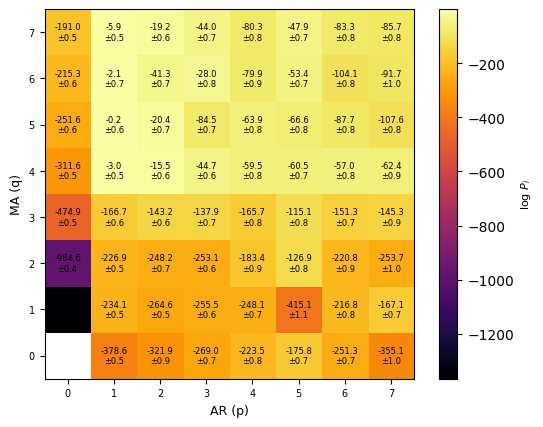

In [10]:
k17_evidence = ar.EvidenceResults("Heatmap Data/kepler17_d1.txt",max_p=7,max_q=7)
k17_evidence.plot_evidence_heatmap(contrast=50)

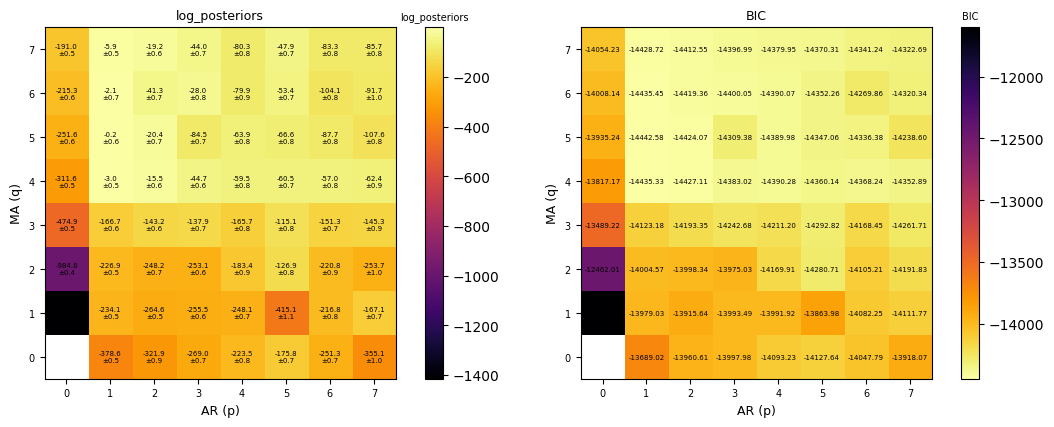

In [11]:
k17_evidence.compare(quantity2="BIC")

In [19]:
model_kepler.summary()

||NESTED SAMPLING SUMMARY RESULTS||
----------------------------------------------------
Nested sampling runtime: 1710.32 seconds
----------------------------------------------------
Posterior mean for phi_1 : 0.9977923964004571
Posterior mean for theta_1 : 0.3849398968443713
Posterior mean for theta_2 : 0.07927889654154774
Posterior mean for theta_3 : -0.2736726927782577
Posterior mean for theta_4 : -0.6556332264709909
Posterior mean for theta_5 : -0.09710541450638792
Posterior mean for sigma : 0.001972971846327027
Posterior mean for mu : 0.0001233830912492498
Posterior mean for init_y_1 : 2.4375576247539404e-05
---------------------------------------------------
Log Evidence: 7194.37 ± 0.25
-------x----------------x-------------x------------


In [12]:
logp = k17_evidence.log_posteriors
errors = k17_evidence.evidence_err
print(f"ARIMA(1,1,5) best model with logP : {np.max(logp)} and err:{errors[np.argmax(logp)]}")
k17_evidence.cumulative_posterior_mass(5)

ARIMA(1,1,5) best model with logP : -0.19353872026294994 and err:0.6204829838273289


{'n': 5,
 'top_orders': [(1, 1, 5), (1, 1, 6), (1, 1, 4), (1, 1, 7), (2, 1, 4)],
 'individual_mass': array([8.24037929e-01, 1.21642285e-01, 5.15319078e-02, 2.78768822e-03,
        1.84162208e-07]),
 'cumulative_mass': 0.9999999939894038}

In [ ]:
#model_kepler.posterior_samples.to_csv('NS Chains/kepler_17_samples.csv')

PosteriorResults: order=(1, 1, 5), prior_type='normal' (inferred from chain)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


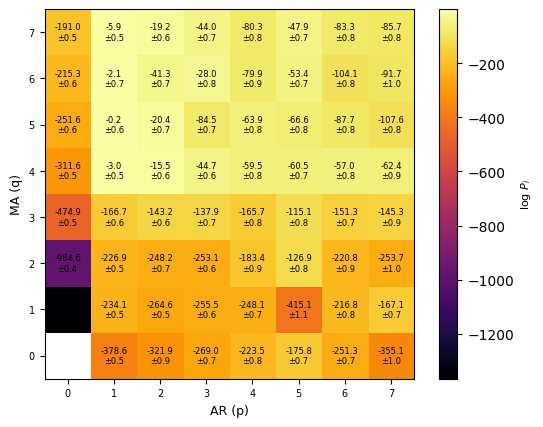

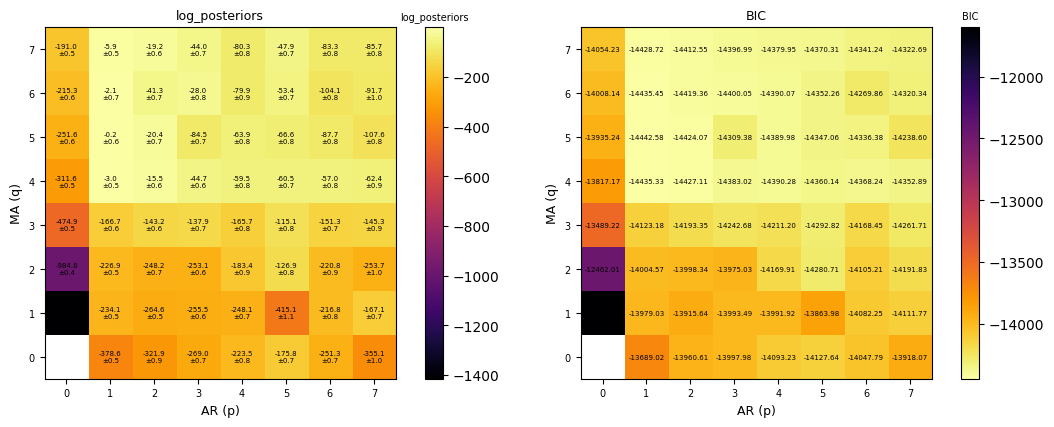

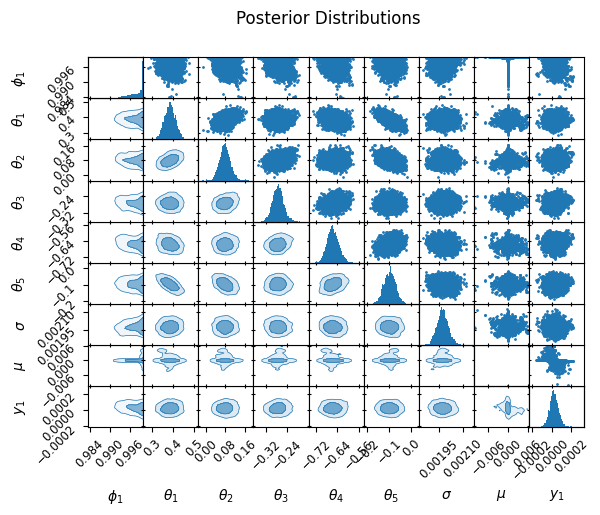

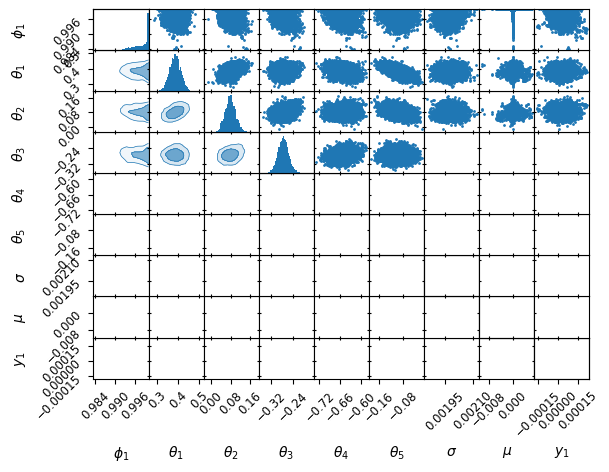

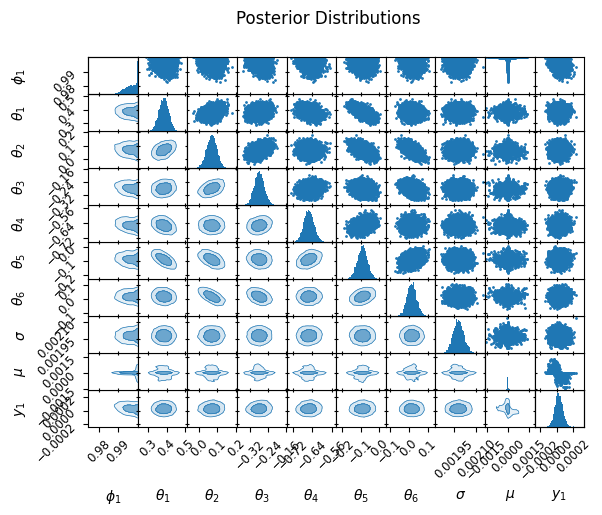

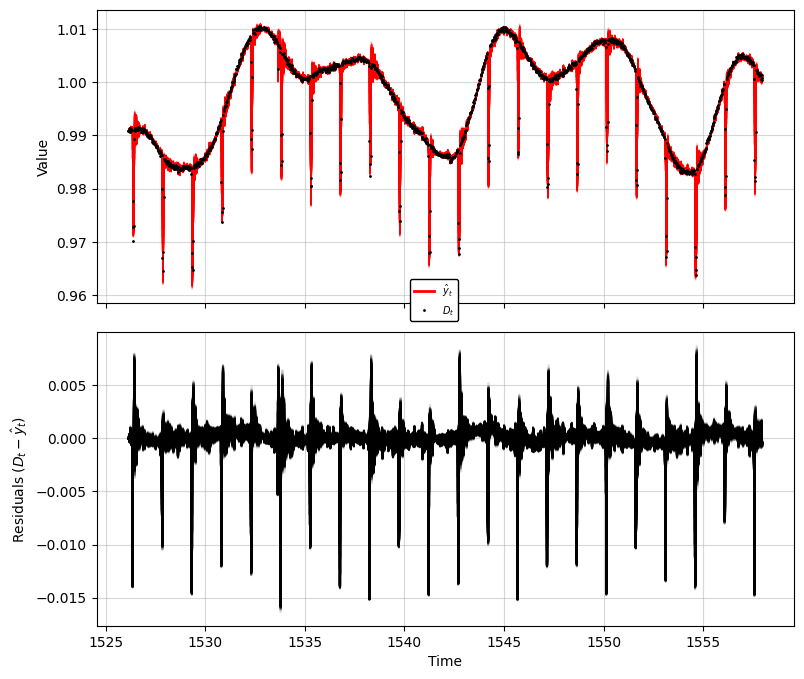

In [19]:
model_15_posterior = ar.PosteriorResults("NS Chains/kepler_17_samples.csv",flux,d=1)
model_15_posterior.insample_forecast(time,deterministic=True)
plt.show()

In [90]:
pooled_resids = model_15_posterior.pooled_residuals()

Pooled residuals: 100%|██████████| 1000/1000 [00:00<00:00, 2275.27it/s]


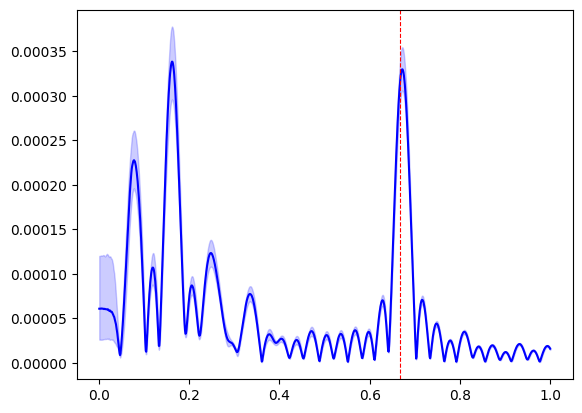

In [91]:
freq = np.linspace(0.001, 1, 1000)
power_matrix = np.array([
    LightCurve(time=time, flux=r).to_periodogram(frequency=freq).power.value
    for r in pooled_resids
])
median_power = np.median(power_matrix, axis=0)
lo, hi = np.percentile(power_matrix, [16, 84], axis=0)

plt.plot(freq, median_power, color='blue')
plt.fill_between(freq, lo, hi, alpha=0.2, color='blue')
plt.axvline(1/1.5, linestyle='--', lw=0.8, c='red')
plt.show()

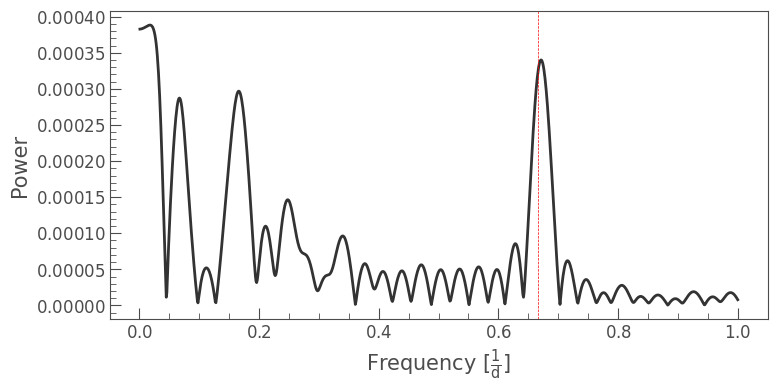

In [22]:
k17_residual = model_15_posterior.point_estimate_forecast()['residuals']
residual_lc = LightCurve(time=time,flux=k17_residual)
freq = np.linspace(0.001,1,1000)

resid_pg= residual_lc.to_periodogram(frequency=freq)
resid_pg.plot(linewidth=2)

plt.axvline(x=1/1.5,linestyle='--',lw=0.5,alpha=1,c='red')

plt.show()

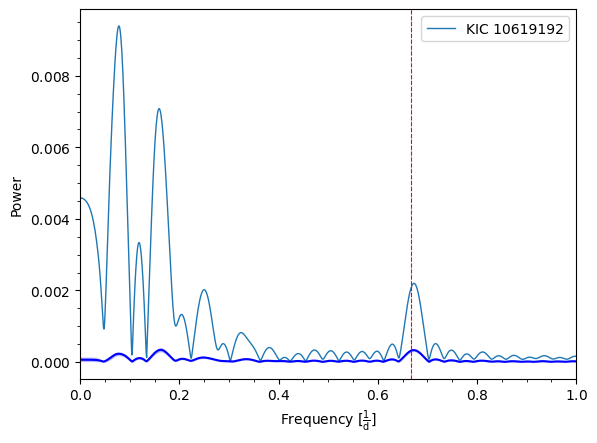

In [93]:
fig,ax = plt.subplots(1,1)
lc_pg = lc.to_periodogram(frequency=freq)
lc_pg.plot(linewidth=1,ax=ax)
ax.axvline(x=1/1.5,linestyle='--',lw=0.5,alpha=0.5)
freq = np.linspace(0.001, 1, 1000)
power_matrix = np.array([
    LightCurve(time=time, flux=r).to_periodogram(frequency=freq).power.value
    for r in pooled_resids
])
median_power = np.median(power_matrix, axis=0)
lo, hi = np.percentile(power_matrix, [16, 84], axis=0)

ax.plot(freq, median_power, color='blue')
ax.fill_between(freq, lo, hi, alpha=0.2, color='blue')
ax.axvline(1/1.5, linestyle='--', lw=0.8, c='red')


ax.set_xlim(0,1)
plt.legend(loc="upper right")
plt.show()

In [94]:
print(f"Orbital period at maximum power from residuals periodogram : {1/resid_pg.frequency_at_max_power}")
print(f"Orbital period at maximum power from lightcurve periodogram : {1/lc_pg.frequency_at_max_power}")

Orbital period at maximum power from residuals periodogram : 6.172839506172839 d
Orbital period at maximum power from lightcurve periodogram : 12.820512820512821 d


In [96]:
resid_frequencies = resid_pg.frequency
resid_powers = resid_pg.power
resid_power_freq_index = np.where(resid_frequencies<=0.078*1/u.day)[0][-1]
resid_freq_noise = resid_frequencies[resid_power_freq_index]
resid_noise_power = resid_powers[resid_power_freq_index]
exoplanet_freq_index_resid = np.where(resid_frequencies<=0.6666 * 1/u.day)[0][-1]
exoplanet_power_resid = resid_pg.power[exoplanet_freq_index_resid]

resid_snr = exoplanet_power_resid/resid_noise_power
print(resid_snr)

noise_floor_resid = np.median(resid_powers)

snr_resid = exoplanet_power_resid/noise_floor_resid
print(snr_resid)

1.106827897407085
2.2956070930428933


In [97]:
lc_frequencies = lc_pg.frequency
lc_powers = lc_pg.power
max_power_freq_index = np.where(lc_frequencies<=0.078*1/u.day)[0][-1]
max_freq_noise = lc_frequencies[max_power_freq_index]
max_noise_power = lc_powers[max_power_freq_index]
exoplanet_freq_index = np.where(lc_frequencies<=0.6666 * 1/u.day)[0][-1]
exoplanet_power = lc_pg.power[exoplanet_freq_index]

lc_snr = exoplanet_power/max_noise_power
print(lc_snr)

noise_floor = np.median(lc_powers)

snr = exoplanet_power/noise_floor
print(snr)

0.2146516803223961
7.308373437946023


In [ ]:
import statsmodels.api as sm
sm.stats.acorr_ljungbox(k17_residual, lags=np.arange(10,21,1), return_df=True,model_df=6)

,lb_stat,lb_pvalue
10,2.829297,0.586786
11,3.205731,0.668302
12,4.150784,0.656280
13,4.845174,0.678851
14,6.365306,0.606383
15,7.110279,0.625639
16,8.974623,0.534514
17,9.709443,0.556697
18,11.503041,0.486369
19,12.397726,0.495331


In [45]:
lags = np.arange(10,81,1)
results = sm.stats.acorr_ljungbox(k17_residual, lags=lags, return_df=True,model_df=6)
p_vals = results.lb_pvalue.to_numpy()
lags[np.argmin(p_vals)]

np.int64(75)

In [99]:
lc_frequencies = lc_pg.frequency
lc_powers = lc_pg.power
max_power_freq_index = np.where(lc_frequencies<=0.078*1/u.day)[0][-1]
max_freq_noise = lc_frequencies[max_power_freq_index]
max_noise_power = lc_powers[max_power_freq_index]
exoplanet_freq_index = np.where(lc_frequencies<=0.6666 * 1/u.day)[0][-1]
exoplanet_power = lc_pg.power[exoplanet_freq_index]

lc_snr = exoplanet_power/max_noise_power
print(lc_snr)

0.2146516803223961


In [100]:
max_power_freq_index = np.where(resid_frequencies<=0.078*1/u.day)[0][-1]
max_freq_noise = resid_frequencies[max_power_freq_index]
max_noise_power = resid_powers[max_power_freq_index]
exoplanet_freq_index = np.where(resid_frequencies<=0.6666 * 1/u.day)[0][-1]
exoplanet_power = resid_pg.power[exoplanet_freq_index]

lc_snr = exoplanet_power/max_noise_power
print(lc_snr)

1.106827897407085
